# BÀI THỰC HÀNH SỐ 5: DỰ ĐOÁN KHẢ NĂNG MẮC BỆNH TIM MẠCH
## 1. Khai báo thư viện
Phần này chúng ta import các thư viện cần thiết như Pandas để xử lý dữ liệu, Scikit-learn để xây dựng mô hình học máy và Matplotlib/Seaborn để vẽ biểu đồ so sánh.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện cho tiền xử lý và chia dữ liệu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Thư viện cho các mô hình học máy
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Thư viện để đánh giá mô hình
from sklearn.metrics import accuracy_score, classification_report

## 2. Tải và đọc dữ liệu
Sử dụng link raw chứa bộ dữ liệu Heart Disease chuẩn xác với yêu cầu.

In [4]:
# Link raw chứa dữ liệu Heart Disease (tương đương với bộ dữ liệu trên Kaggle)
data_url = "https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv"

# Đọc dữ liệu trực tiếp từ link
df = pd.read_csv(data_url)

# Hiển thị 5 dòng đầu tiên
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Tiền xử lý dữ liệu
- **Tách dữ liệu:** Tách cột `target` (có bệnh hay không) ra làm nhãn (y), các cột còn lại làm đặc trưng (X).
- **Chia tập dữ liệu:** Chia thành tập huấn luyện (Train) 80% và tập kiểm thử (Test) 20%.
- **Chuẩn hóa (Scaling):** Đưa các giá trị về cùng một thang đo. Rất quan trọng với thuật toán KNN để đo khoảng cách chính xác.

In [5]:
# Tách đặc trưng (X) và biến mục tiêu (y)
X = df.drop('target', axis=1)
y = df['target']

# Chia dữ liệu: 80% để train, 20% để test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo công cụ chuẩn hóa
scaler = StandardScaler()

# Chỉ fit (tìm trung bình, độ lệch chuẩn) trên tập train và biến đổi nó
X_train_scaled = scaler.fit_transform(X_train)

# Áp dụng thang đo đó cho tập test
X_test_scaled = scaler.transform(X_test)

print("Kích thước tập huấn luyện:", X_train_scaled.shape)
print("Kích thước tập kiểm thử:", X_test_scaled.shape)

Kích thước tập huấn luyện: (242, 13)
Kích thước tập kiểm thử: (61, 13)


## 4. Huấn luyện mô hình
Chúng ta sẽ khởi tạo và huấn luyện 3 thuật toán:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Random Forest

In [6]:
# 1. Khởi tạo các mô hình
log_reg = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5) # Chọn thử K=5
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Huấn luyện các mô hình với dữ liệu đã chuẩn hóa
log_reg.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

print("Đã huấn luyện xong 3 mô hình!")

Đã huấn luyện xong 3 mô hình!


## 5. Đánh giá và so sánh các mô hình
- Dự đoán kết quả trên tập kiểm thử (Test).
- Tính độ chính xác (Accuracy).
- Trực quan hóa kết quả bằng biểu đồ cột.


Độ chính xác của Logistic Regression: 85.25%
Độ chính xác của KNN: 90.16%
Độ chính xác của Random Forest: 83.61%


/tmp/ipykernel_1697/764823222.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


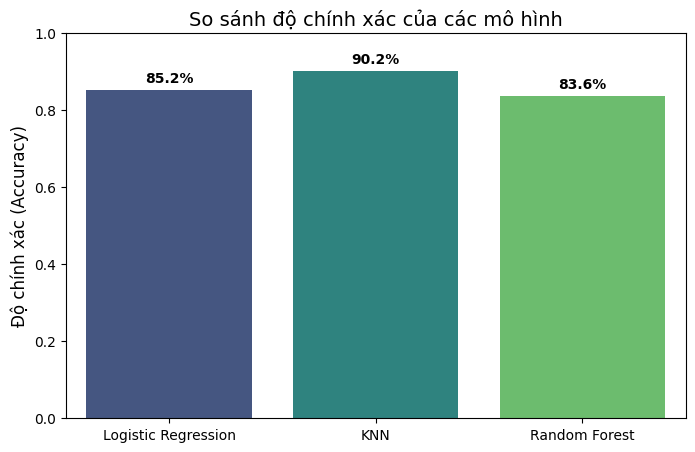

In [7]:
# Dự đoán trên tập kiểm thử
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

# Tính toán độ chính xác (Accuracy)
acc_log = accuracy_score(y_test, y_pred_log)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_rf = accuracy_score(y_test, y_pred_rf)

# In kết quả
print(f"Độ chính xác của Logistic Regression: {acc_log * 100:.2f}%")
print(f"Độ chính xác của KNN: {acc_knn * 100:.2f}%")
print(f"Độ chính xác của Random Forest: {acc_rf * 100:.2f}%")

# Vẽ biểu đồ so sánh
models = ['Logistic Regression', 'KNN', 'Random Forest']
accuracies = [acc_log, acc_knn, acc_rf]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('So sánh độ chính xác của các mô hình', fontsize=14)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
plt.ylim(0, 1) # Giới hạn trục y từ 0 đến 1 (tức là 0% - 100%)

# Hiển thị số liệu trực tiếp trên từng cột biểu đồ
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

plt.show()